In [1]:
import hoda
import tensorly as tl
tl.get_backend()
import cupyx
cupyx.seterr(linalg='raise')

{'divide': None,
 'over': None,
 'under': None,
 'invalid': None,
 'linalg': 'ignore',
 'fallback_mode': 'ignore'}

In [16]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.


Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


In [17]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
4195,1,0,0
4196,1,0,0
4197,1,0,0
4198,1,0,0


In [18]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 26)

In [19]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import warnings
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

bttda = BTTDA(
    max_blocks=16,
    info_crit='bic',
    hoda_params=dict(
        rank=1,
        max_iter=1024,
        tol=1e-16,
        init ='svd',
        shrinkage='lw',
        toeplitz=(1,),
        obj='rt',
        solver='lobpcg',
        taper=False,
        extra_train_info=False,
        verbose=True,
       
    ),
    verbose=True,
    extra_train_info=True,
)

%lprun -f bttda.fit bttda.fit(X,y)

Fitting block 1/16...
Fitting discriminative Tucker model of rank (1, 1)...


  0%|          | 0/1024 [00:00<?, ?it/s]

Fitting discriminative Tucker model of rank (2, 2)...


  0%|          | 0/1024 [00:00<?, ?it/s]

Fitting discriminative Tucker model of rank (3, 3)...


...

Fitting discriminative Tucker model of rank (2, 2)...


  0%|          | 0/1024 [00:00<?, ?it/s]

Fitting discriminative Tucker model of rank (3, 3)...


  0%|          | 0/1024 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 39.0259 s
File: /project/src/hoda/hoda.py
Function: fit at line 530

Line #      Hits         Time  Per Hit   % Time  Line Contents
   530                                               def fit(self, X, y=None):
   531         1   14851145.0    1e+07      0.0          X = tl.tensor(X.copy())
   532         1       9883.0   9883.0      0.0          n_samples, *shape = X.shape
   533         1       2571.0   2571.0      0.0          hoda_params = self.hoda_params or dict()
   534         1       3040.0   3040.0      0.0          self.blocks_ = []
   535         1        630.0    630.0      0.0          if self.extra_train_info:
   536         1       1755.0   1755.0      0.0              self.train_info_ = []
   537                                           
   538         1       2582.0   2582.0      0.0          crit_value = np.inf
   539         1     180961.0 180961.0      0.0          err = X.copy()
   540                                           
  

In [20]:
bttda.train_info_

,log_like,n_params,bic,aic,aicc,rank,mse
block,,,,,,,
1,-1371.876174,102,2818.837906,2761.752347,2761.795307,"(3, 3)",6.906880e-11
2,-1368.305080,136,2820.038558,2756.610160,2756.662678,"(1, 1)",6.927463e-11
3,-1366.501364,170,2824.773966,2755.002728,2755.065766,"(1, 1)",6.876243e-11
4,-1316.152172,306,2857.561020,2686.304345,2686.666761,"(4, 4)",6.630090e-11
5,-1313.483884,374,2885.595802,2688.967768,2689.443775,"(2, 2)",6.504716e-11
6,-1307.500289,442,2906.999971,2685.000578,2685.605766,"(2, 2)",6.459309e-11
7,-1306.390943,510,2938.152639,2690.781886,2691.531886,"(2, 2)",6.377418e-11
8,-1305.042877,544,2943.799347,2690.085755,2690.874406,"(1, 1)",6.372276e-11
9,-1303.376610,578,2948.809652,2688.753220,2689.581503,"(1, 1)",6.347303e-11


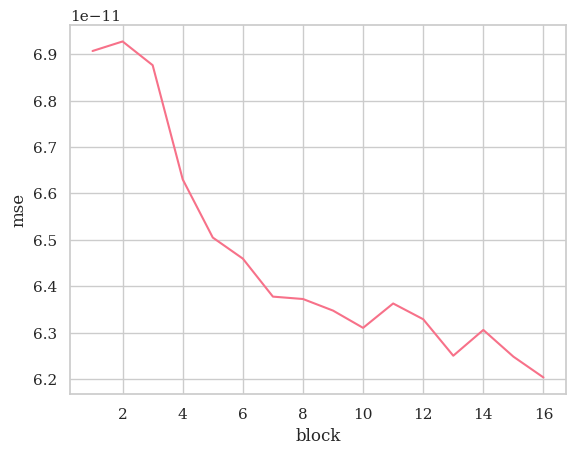

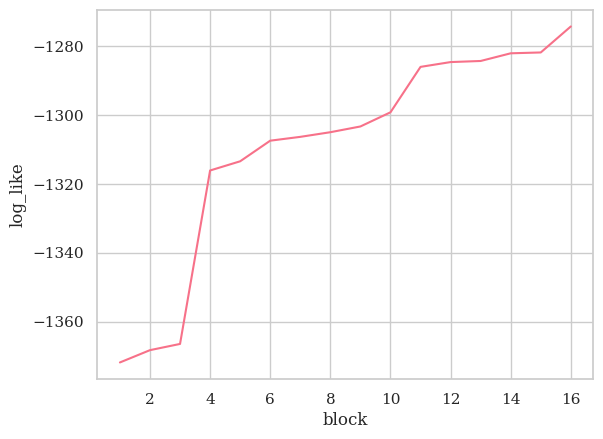

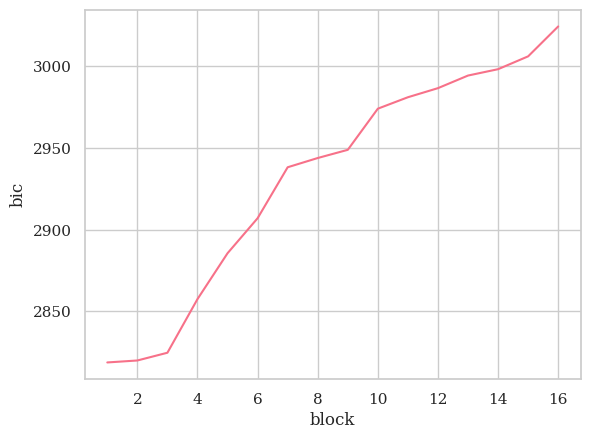

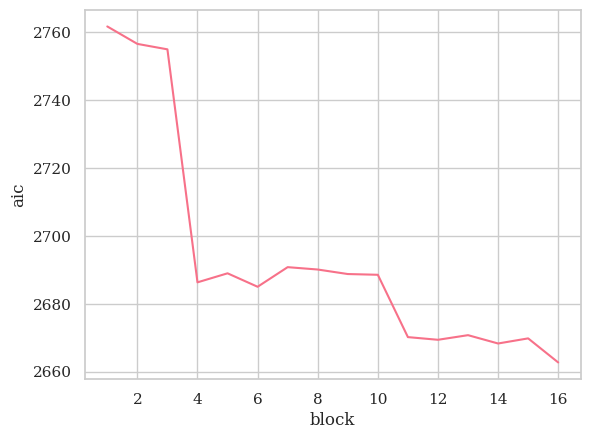

<Axes: xlabel='block', ylabel='aicc'>

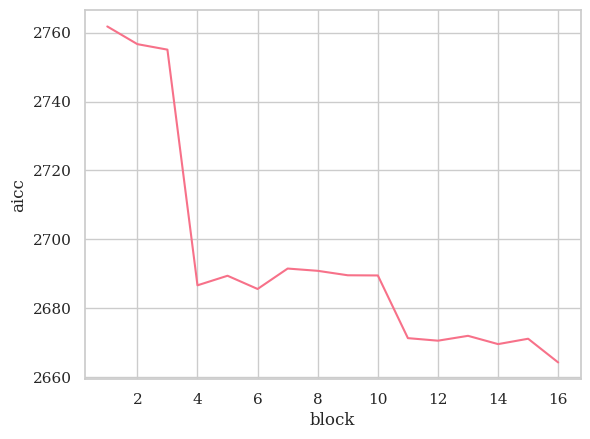

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from hoda.hoda import log_likelihood, aic
n_samples = X.shape[0]
sns.lineplot(data=bttda.train_info_, x='block', y='mse')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='log_like')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='bic')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='aic')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='aicc')


In [8]:
Xt = bttda.transform(X)

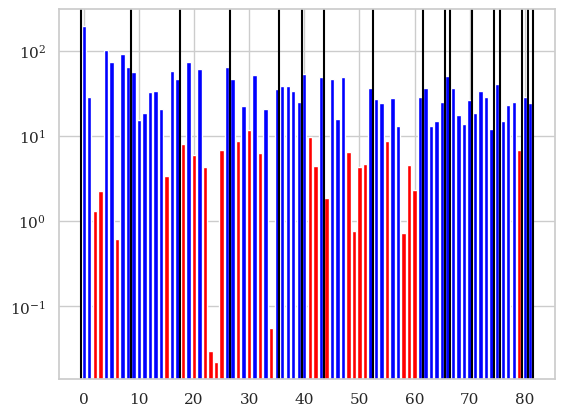

In [9]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < (0.05/len(p))
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b in bttda.blocks_:
    n_params+=math.prod(b.ml_rank_)
    plt.axvline(n_params-.5, color='black')


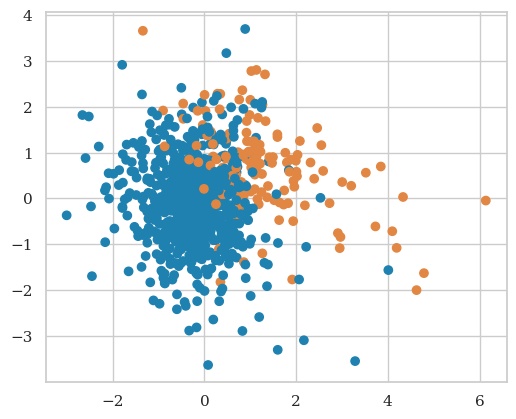

In [10]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [11]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


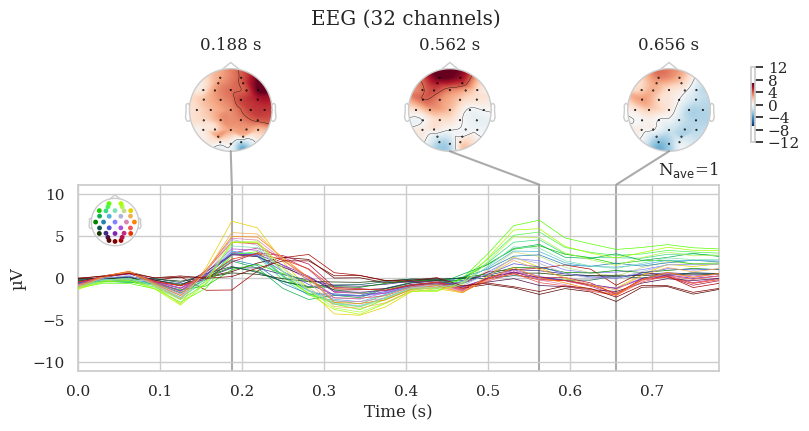

No projector specified for this dataset. Please consider the method self.add_proj.


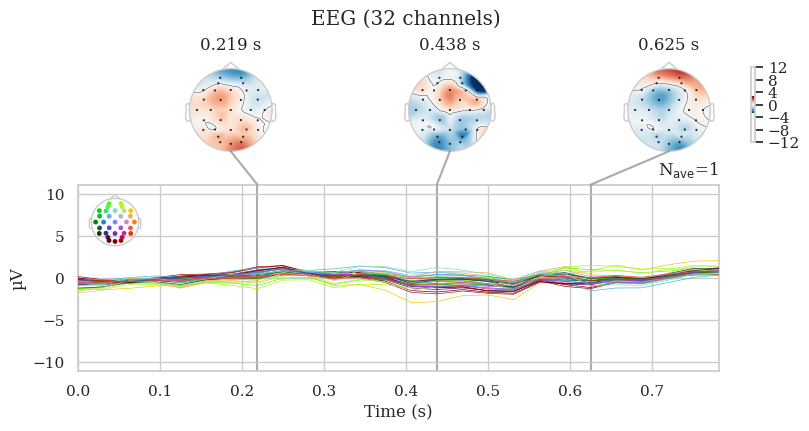

No projector specified for this dataset. Please consider the method self.add_proj.


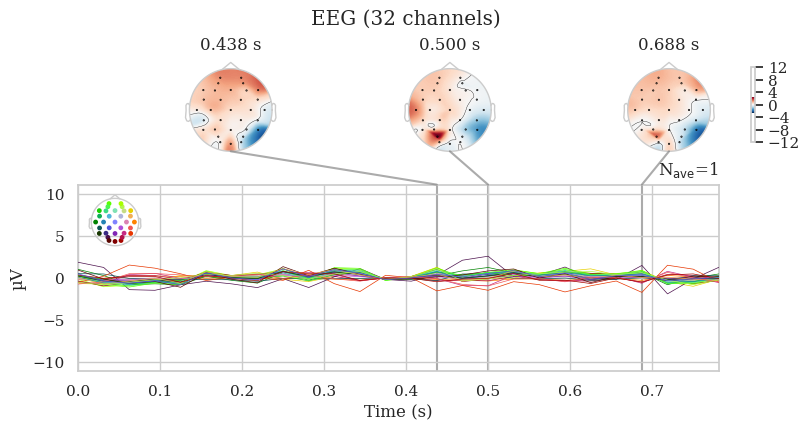

No projector specified for this dataset. Please consider the method self.add_proj.


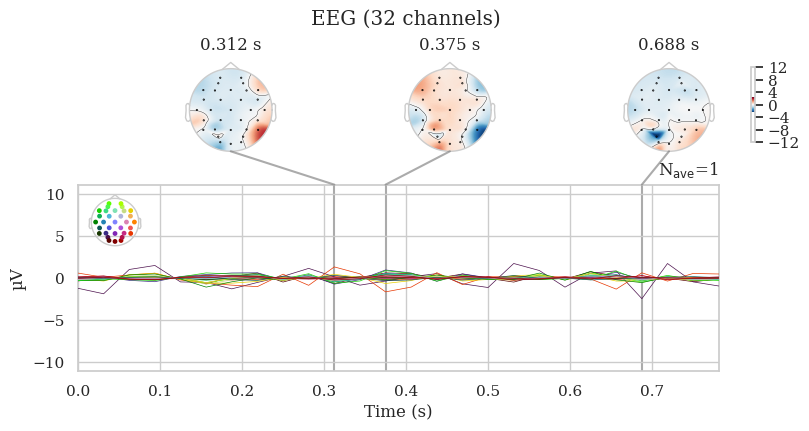

No projector specified for this dataset. Please consider the method self.add_proj.


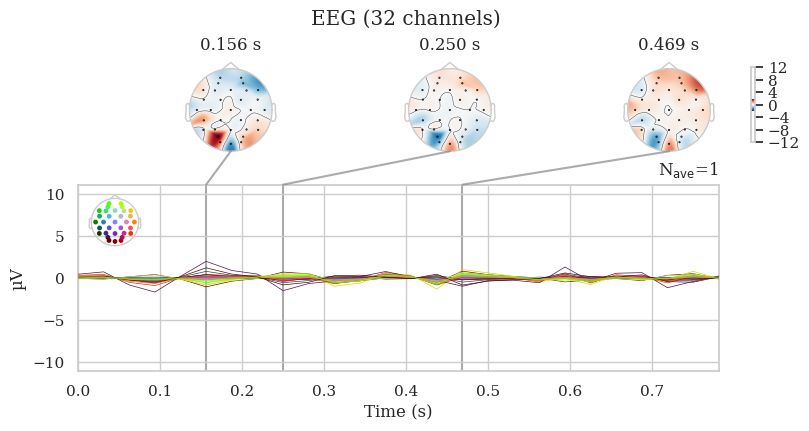

No projector specified for this dataset. Please consider the method self.add_proj.


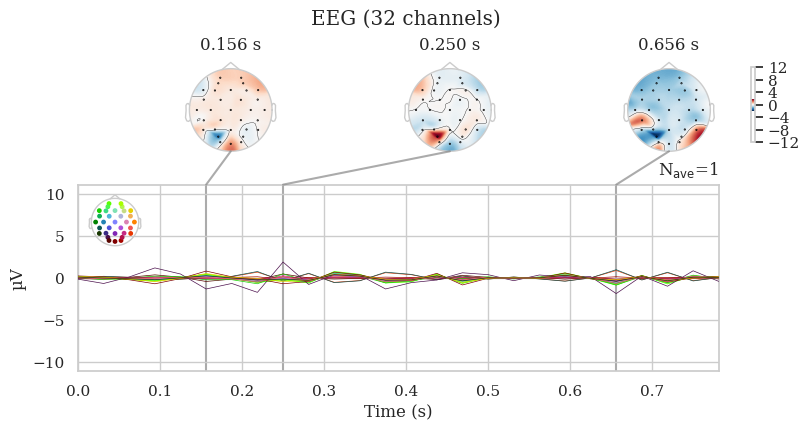

No projector specified for this dataset. Please consider the method self.add_proj.


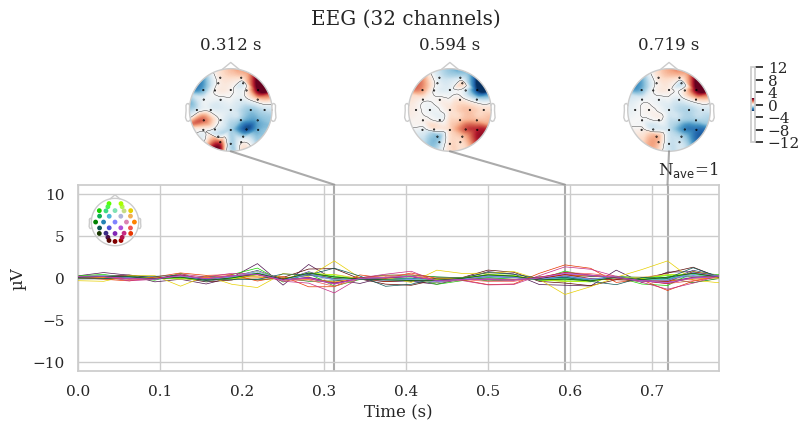

No projector specified for this dataset. Please consider the method self.add_proj.


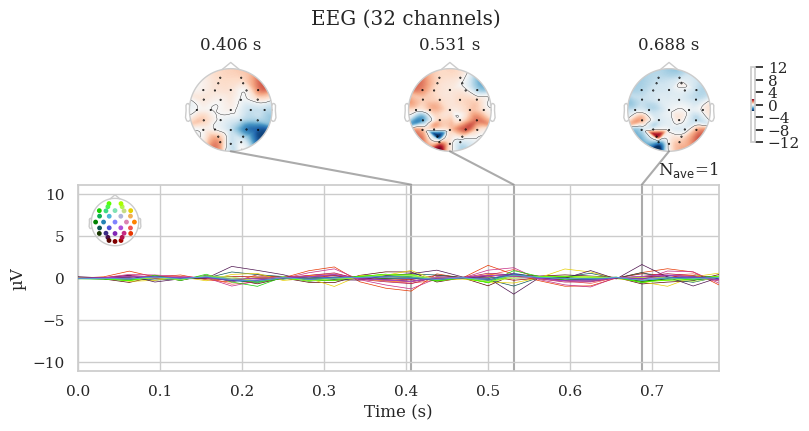

No projector specified for this dataset. Please consider the method self.add_proj.


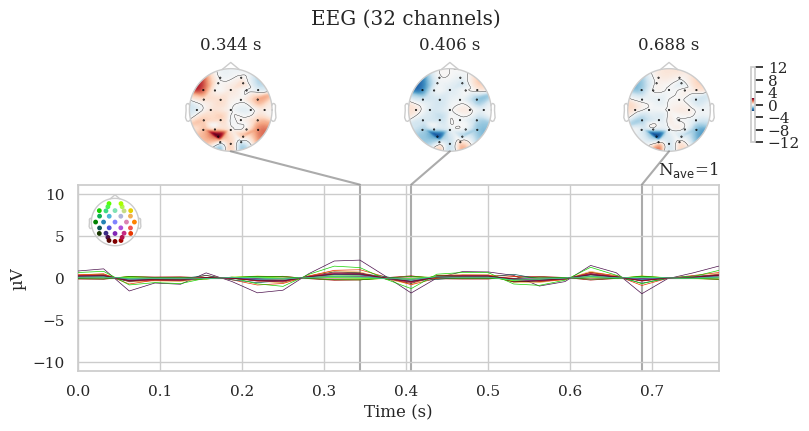

No projector specified for this dataset. Please consider the method self.add_proj.


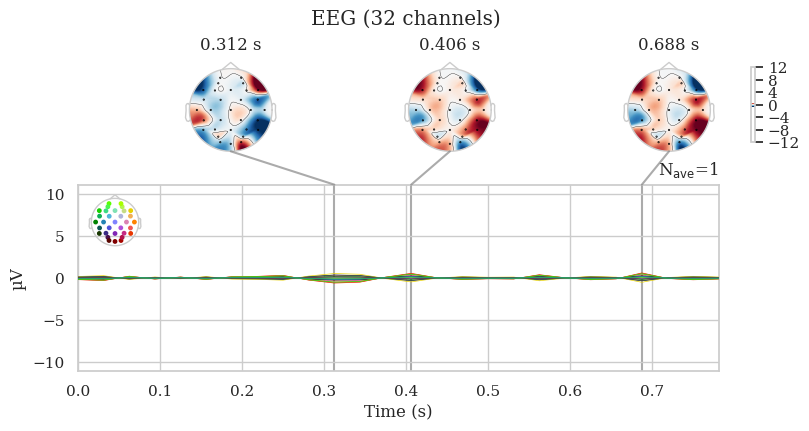

No projector specified for this dataset. Please consider the method self.add_proj.


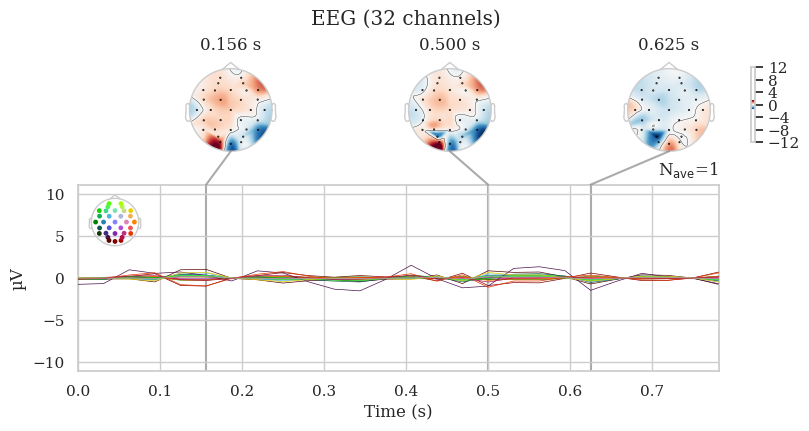

No projector specified for this dataset. Please consider the method self.add_proj.


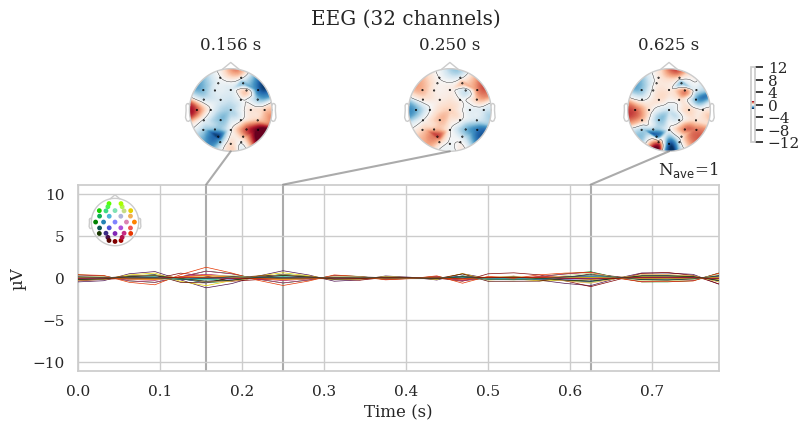

No projector specified for this dataset. Please consider the method self.add_proj.


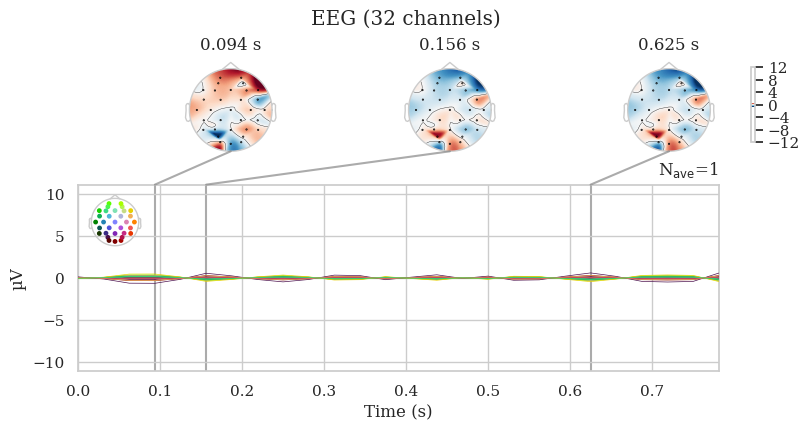

No projector specified for this dataset. Please consider the method self.add_proj.


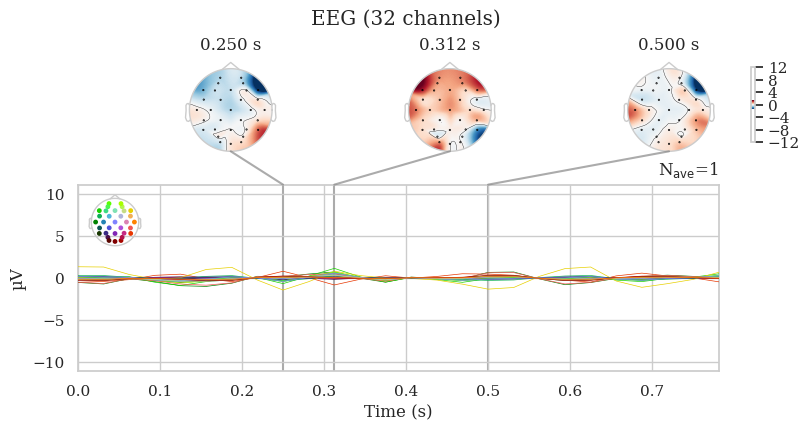

No projector specified for this dataset. Please consider the method self.add_proj.


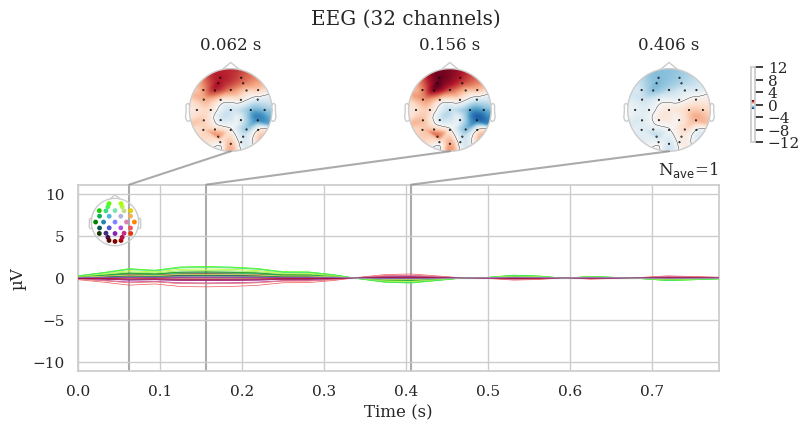

No projector specified for this dataset. Please consider the method self.add_proj.


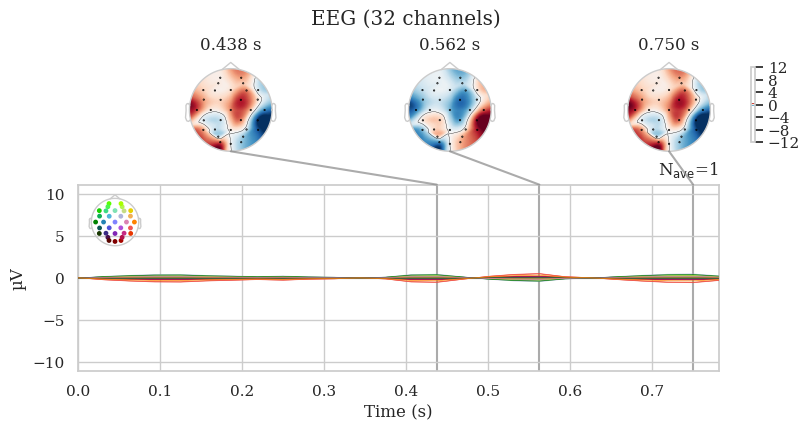

In [12]:
from mne import EvokedArray
for b in bttda.blocks_:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

In [13]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    #if len(evoked_rec.ch_names) > 1:
    #    evoked_rec.plot_joint(title=cls,**joint_args)
    #else:
    #    evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


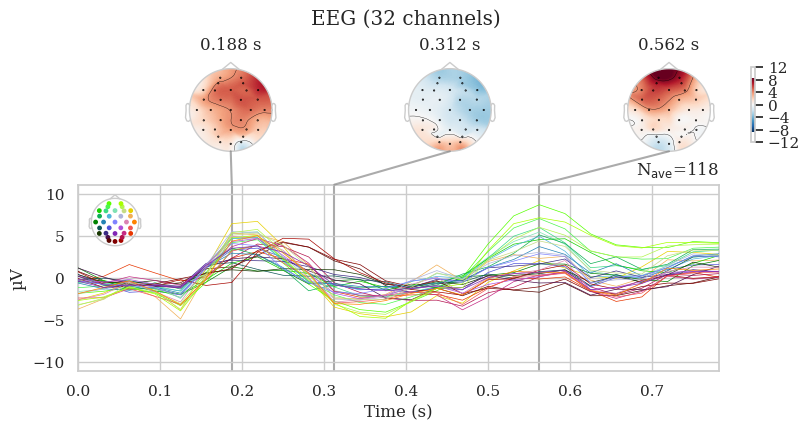

No projector specified for this dataset. Please consider the method self.add_proj.


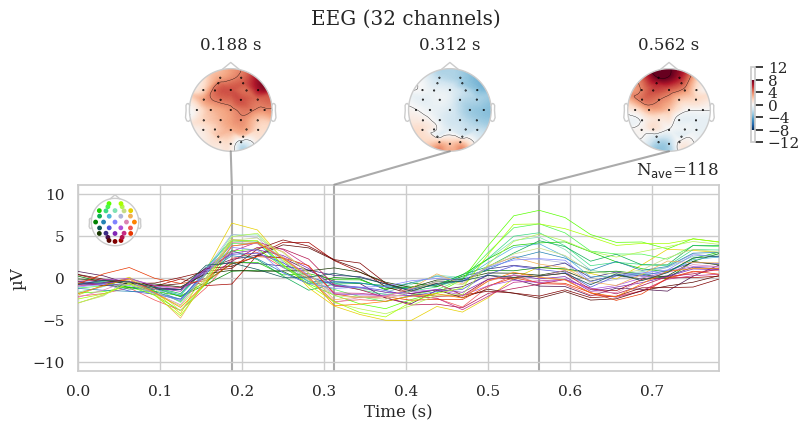

In [14]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


No projector specified for this dataset. Please consider the method self.add_proj.


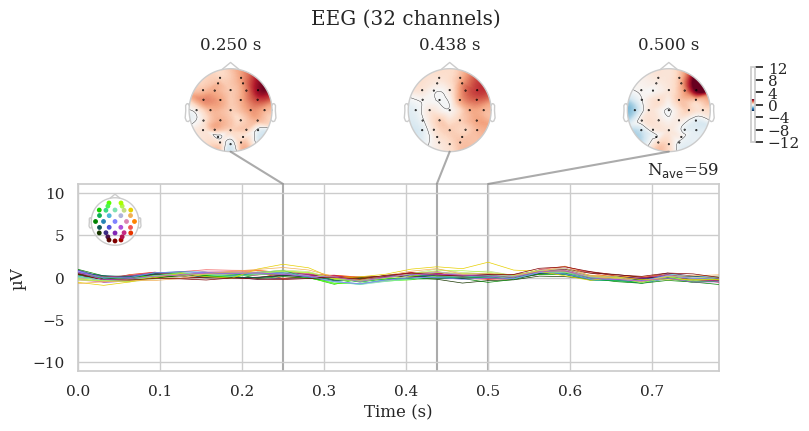

In [15]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)